In [ ]:
# STEP 1: Setup
from urllib.request import urlretrieve
from pathlib import Path
import pandas as pd

# Download file if not already available
if not Path("rooster_a3_colours.xlsx").exists():
    urlretrieve(
        "https://drive.google.com/uc?export=download&id=14_my2Q7kIhIRo8d7TGoM9ujCCwwmtgbU",
        "rooster_a3_colours.xlsx"
    )

# STEP 2: Load sheets
excel_file = pd.ExcelFile("rooster_a3_colours.xlsx")
products_df = excel_file.parse("products")
orderlines_df = excel_file.parse("orderlines")
orders_df = excel_file.parse("orders")
metrics_df = excel_file.parse("metrics")

# STEP 3: Merge orderlines with products
merged_df = pd.merge(orderlines_df, products_df, on="pvr_id", how="left")

# STEP 4: Setup ID types and basic columns
merged_df["order_id"] = merged_df["order_id"].astype(str)
orders_df["order_id"] = orders_df["order_id"].astype(str)

# Assign brand tag
merged_df["brand"] = merged_df["range"].apply(lambda x: "Eve" if "Eve" in str(x) else "Adam")

# Tag headers/components (but keep full dataset)
merged_df["is_bundle_header"] = (merged_df["colour"].str.lower() == "custom") & (merged_df["item_price_inc_tax"] > 0)
merged_df["is_bundle_component"] = (merged_df["item_price_inc_tax"] == 0) & (merged_df["colour"].str.lower() != "custom")

# STEP 5: Assign costs to components
eve_cost_map = {
    "Bra": 5.64,
    "Thong": 3.04,
    "Bikini Brief": 3.28,
    "Full Brief": 3.52
}

def assign_cost(row):
    if "Eve" in str(row["range"]):
        return eve_cost_map.get(row["product_type"], 0)
    elif "Adam" in str(row["range"]):
        return 4.00
    else:
        return 0.00

merged_df["cost"] = merged_df.apply(assign_cost, axis=1)

# STEP 6: Calculate component costs for bundle reconstruction
components_df = merged_df[merged_df["is_bundle_component"]].copy()
components_df["component_cost"] = components_df["cost"] * components_df["qty_minus_refund"]

composition_summary = components_df.groupby("order_id").agg(
    bundle_component_cost=("component_cost", "sum"),
    all_brands=("brand", lambda x: set(x)),
    colours_in_bundle=("colour", lambda x: ", ".join(sorted(set(x.astype(str)))))
).reset_index()

def classify_brand(brand_set):
    if brand_set == {"Adam"}:
        return "Adam"
    elif brand_set == {"Eve"}:
        return "Eve"
    else:
        return "Mixed"

composition_summary["bundle_type"] = composition_summary["all_brands"].apply(classify_brand)

# STEP 7: Merge bundle data into headers only
headers_df = merged_df[merged_df["is_bundle_header"]].copy()

headers_df = headers_df.merge(composition_summary, on="order_id", how="left")
headers_df["true_bundle_profit"] = headers_df["item_price_inc_tax"] - headers_df["bundle_component_cost"]

# Add customer info + metrics
headers_df = headers_df.merge(orders_df[["order_id", "customer_email", "order_date"]], on="order_id", how="left")
headers_df = headers_df.merge(metrics_df, on="customer_email", how="left")
headers_df["customer_id"] = headers_df["customer_email"].astype(str)
headers_df["month"] = pd.to_datetime(headers_df["order_date"]).dt.to_period("M")

# STEP 8: Bundle performance for last 7 months
recent_headers = headers_df[headers_df["month"] >= pd.Period("2024-11")]

recent_summary = (
    recent_headers.groupby("bundle_type")
    .agg(
        avg_recent_profit=("true_bundle_profit", "mean"),
        avg_recent_bundles=("order_id", "count"),
        avg_recent_units=("units", "mean"),
        months_included=("month", "nunique")
    )
    .reset_index()
)

# STEP 9: Output Results
print(" Recent 7-Month Bundle Performance (Since Nov 2024):")
print(recent_summary)

# OPTIONAL: merged_df is the full clean dataset (for general sales, predictive models, etc.)


 Recent 7-Month Bundle Performance (Since Nov 2024):
  bundle_type  avg_recent_profit  avg_recent_bundles  avg_recent_units  \
0        Adam          44.761339                1725          5.046957   
1         Eve          31.686128                 470          4.591489   
2       Mixed          21.018196                 327          4.935780   

   months_included  
0                7  
1                7  
2                7  


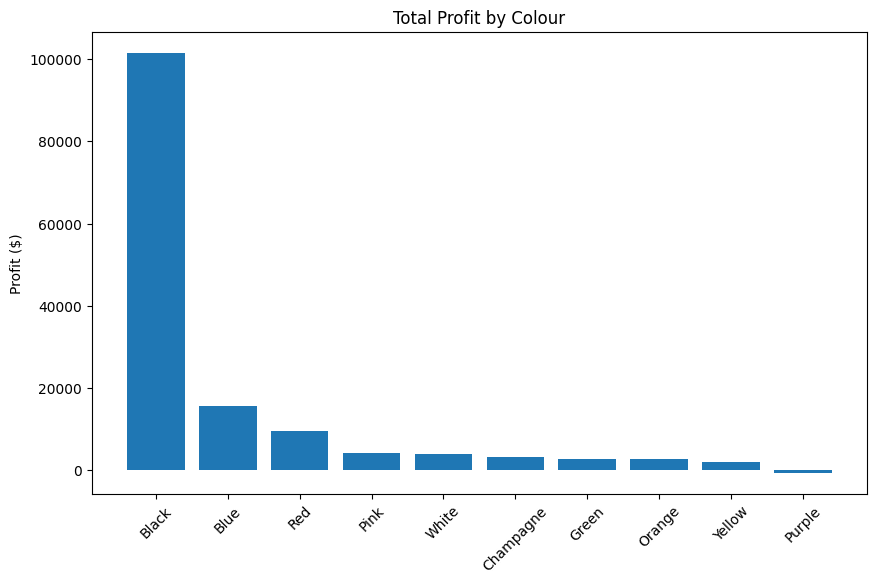

In [ ]:

# Filter for valid rows (non-Custom, units > 0)
valid_sales = merged_df[(merged_df["colour"].str.lower() != "custom") & (merged_df["qty_minus_refund"] > 0)].copy()
valid_sales["profit"] = (valid_sales["item_price_inc_tax"] - valid_sales["cost"]) * valid_sales["qty_minus_refund"]


# Group by colour
colour_profit = valid_sales.groupby("colour").agg(
    total_profit=("profit", "sum"),
    total_units=("units", "sum")
).sort_values(by="total_profit", ascending=False).reset_index()

# Plot
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
plt.bar(colour_profit["colour"], colour_profit["total_profit"])
plt.title("Total Profit by Colour")
plt.xticks(rotation=45)
plt.ylabel("Profit ($)")
plt.show()


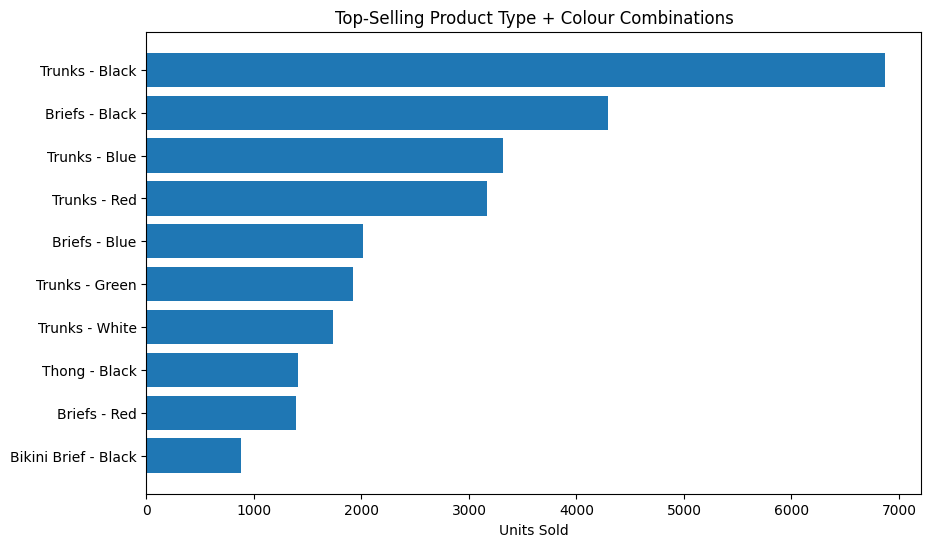

In [ ]:

# Group by product type and colour
top_items = valid_sales.groupby(["product_type", "colour"]).agg(
    total_units=("qty_minus_refund", "sum"),
    total_profit=("profit", "sum")
).sort_values(by="total_units", ascending=False).reset_index()

# Plot
top10 = top_items.head(10)
plt.figure(figsize=(10,6))
plt.barh(top10["product_type"] + " - " + top10["colour"], top10["total_units"])
plt.title("Top-Selling Product Type + Colour Combinations")
plt.xlabel("Units Sold")
plt.gca().invert_yaxis()
plt.show()


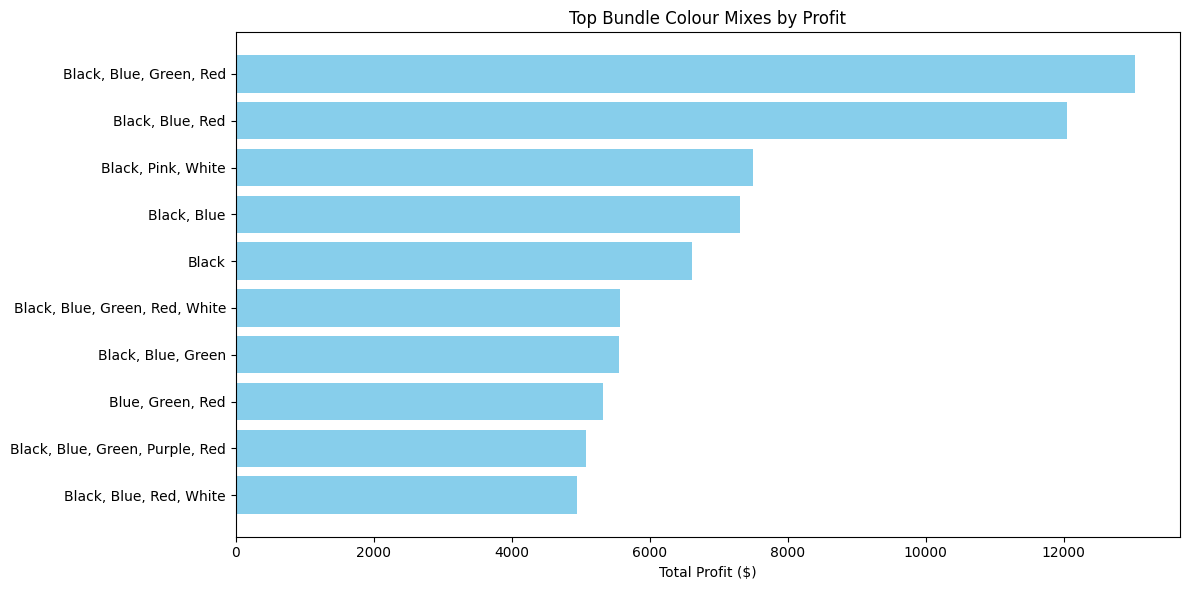

In [ ]:
# Total dataset: ALL products including bundles, variations, components
# Use this for general sales/profit analysis
merged_df["profit"] = (merged_df["item_price_inc_tax"] - merged_df["cost"]) * merged_df["units"]

# ✅ A: Company-wide sales profit by colour
company_profit_summary = (
    merged_df[merged_df["colour"].str.lower() != "custom"]  # exclude headers
    .groupby("colour")
    .agg(
        total_profit=("profit", "sum"),
        total_units=("units", "sum"),
        total_orders=("order_id", "nunique")
    )
    .reset_index()
    .sort_values(by="total_profit", ascending=False)
)

# ✅ B: Bundle-level profit (defined earlier only for bundle headers)
# Use only `headers_df` created earlier
bundle_summary = (
    headers_df.groupby(["bundle_type", "colours_in_bundle"])
    .agg(
        total_profit=("true_bundle_profit", "sum"),
        bundle_count=("order_id", "count")
    )
    .reset_index()
    .sort_values(by="total_profit", ascending=False)
)

# ✅ C: Plot top 10 bundles by profit
import matplotlib.pyplot as plt

top_bundles = bundle_summary.head(10)
plt.figure(figsize=(12, 6))
plt.barh(top_bundles["colours_in_bundle"], top_bundles["total_profit"], color='skyblue')
plt.title("Top Bundle Colour Mixes by Profit")
plt.xlabel("Total Profit ($)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


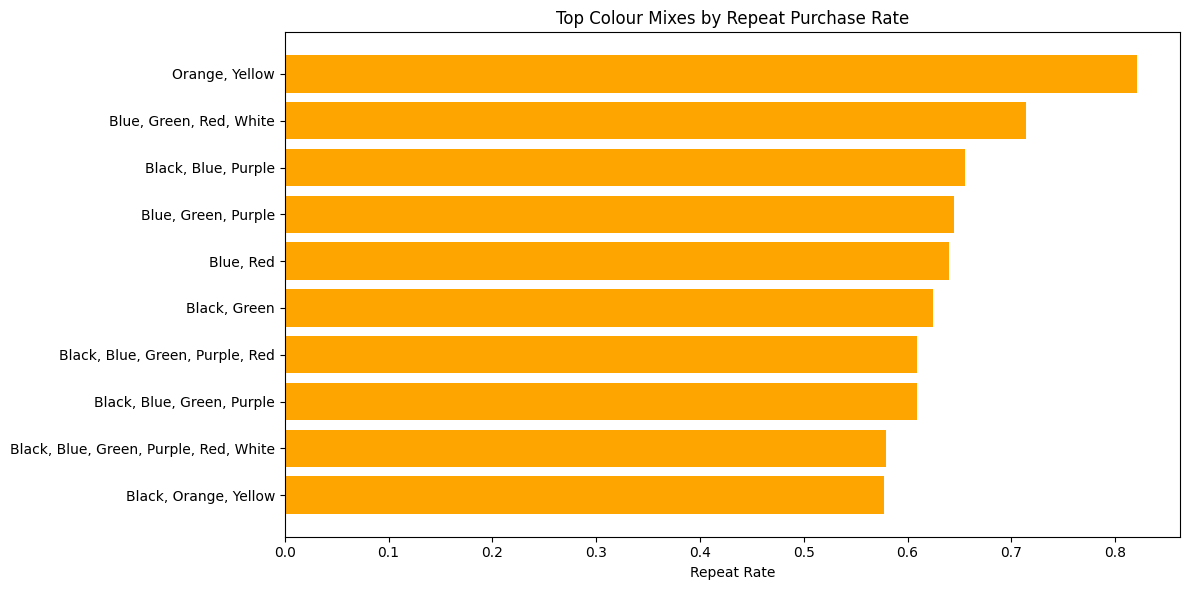

In [ ]:
import matplotlib.pyplot as plt

# Group and calculate repeat rate by colour mix using headers_df
repeat_summary = headers_df.groupby("colours_in_bundle").agg(
    repeat_rate=("repeat_customer", "mean"),
    bundle_count=("order_id", "count")
).sort_values(by="repeat_rate", ascending=False).reset_index()

# Optional: Filter to top colour mixes by order count
top_repeat = repeat_summary[repeat_summary["bundle_count"] > 20].head(10)

# Plot
plt.figure(figsize=(12, 6))
plt.barh(top_repeat["colours_in_bundle"], top_repeat["repeat_rate"], color='orange')
plt.title("Top Colour Mixes by Repeat Purchase Rate")
plt.xlabel("Repeat Rate")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


In [ ]:
top_colour_type_combos = headers_df.groupby(
    ["colours_in_bundle", "bundle_type"]
).agg(
    total_profit=("true_bundle_profit", "sum"),
    bundle_count=("order_id", "count")
).sort_values(by="total_profit", ascending=False).reset_index()

top_colour_type_combos.head(10)


,colours_in_bundle,bundle_type,total_profit,bundle_count
0,"Black, Blue, Green, Red",Adam,13034.23,274
1,"Black, Blue, Red",Adam,12042.78,316
2,"Black, Pink, White",Eve,7499.95,233
3,"Black, Blue",Adam,7316.45,174
4,Black,Adam,6617.13,141
5,"Black, Blue, Green, Red, White",Adam,5575.56,101
6,"Black, Blue, Green",Adam,5556.92,147
7,"Blue, Green, Red",Adam,5321.53,136
8,"Black, Blue, Green, Purple, Red",Adam,5077.14,92
9,"Black, Blue, Red, White",Adam,4953.94,119


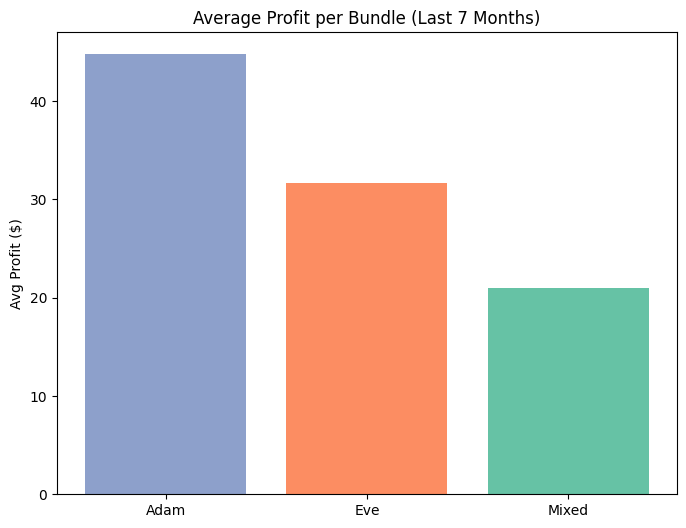

In [ ]:
# Filter for recent 7 months
recent = headers_df[headers_df["month"] >= pd.Period("2024-11")]

# Group by bundle type and calculate summary
summary = recent.groupby("bundle_type").agg(
    avg_profit=("true_bundle_profit", "mean"),
    total_units=("units", "sum"),
    bundle_count=("order_id", "count")
).reset_index()

# Plot
plt.figure(figsize=(8, 6))
plt.bar(summary["bundle_type"], summary["avg_profit"], color=["#8da0cb", "#fc8d62", "#66c2a5"])
plt.title("Average Profit per Bundle (Last 7 Months)")
plt.ylabel("Avg Profit ($)")
plt.show()


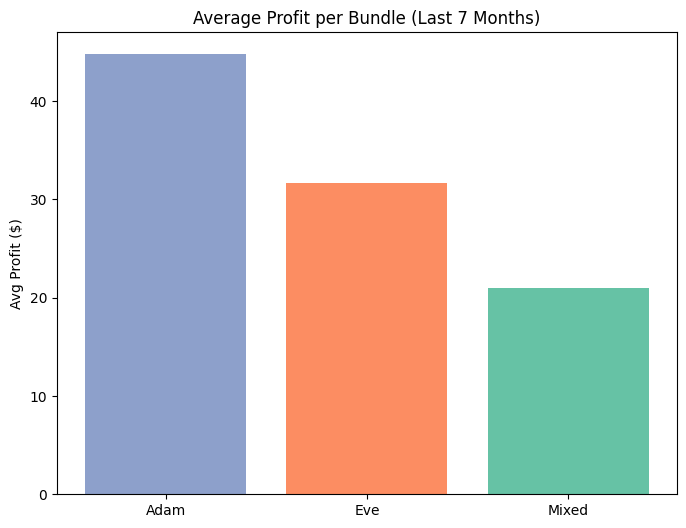

In [ ]:
# Filter for recent 7 months
recent = headers_df[headers_df["month"] >= pd.Period("2024-11")]

summary = recent.groupby("bundle_type").agg(
    avg_profit=("true_bundle_profit", "mean"),
    total_units=("units", "sum"),
    bundle_count=("order_id", "count")
).reset_index()

# Plot
plt.figure(figsize=(8,6))
plt.bar(summary["bundle_type"], summary["avg_profit"], color=["#8da0cb", "#fc8d62", "#66c2a5"])
plt.title("Average Profit per Bundle (Last 7 Months)")
plt.ylabel("Avg Profit ($)")
plt.show()


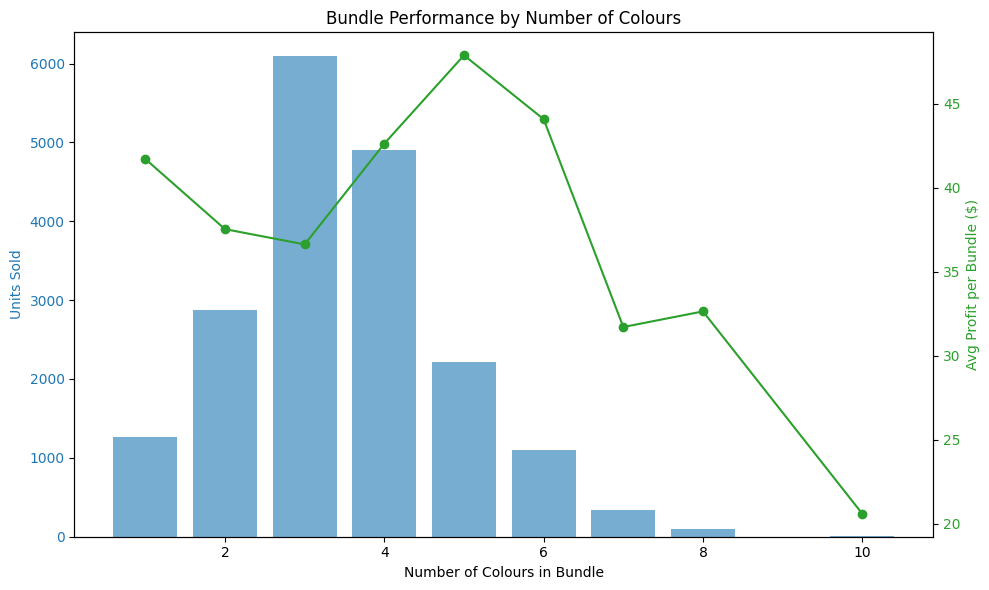

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Make sure 'num_colours' column is created
headers_df["num_colours"] = headers_df["colours_in_bundle"].apply(
    lambda x: len(set(x.split(", "))) if isinstance(x, str) else 1
)

# Aggregate bundle performance by number of colours
bundle_size_comparison = (
    headers_df.groupby("num_colours")
    .agg(
        avg_profit=("true_bundle_profit", "mean"),
        total_profit=("true_bundle_profit", "sum"),
        bundle_count=("order_id", "count"),
        total_units=("units", "sum")
    )
    .sort_values(by="num_colours")
    .reset_index()
)

# Create the visualization
fig, ax1 = plt.subplots(figsize=(10, 6))

color = 'tab:blue'
ax1.set_xlabel('Number of Colours in Bundle')
ax1.set_ylabel('Units Sold', color=color)
ax1.bar(bundle_size_comparison["num_colours"], bundle_size_comparison["total_units"],
        color=color, alpha=0.6, label='Units Sold')
ax1.tick_params(axis='y', labelcolor=color)

# Second y-axis for average profit
ax2 = ax1.twinx()
color = 'tab:green'
ax2.set_ylabel('Avg Profit per Bundle ($)', color=color)
ax2.plot(bundle_size_comparison["num_colours"], bundle_size_comparison["avg_profit"],
         color=color, marker='o', label='Avg Profit')
ax2.tick_params(axis='y', labelcolor=color)

plt.title("Bundle Performance by Number of Colours")
plt.tight_layout()
plt.show()


In [ ]:
# Create customer-level summary from headers_df
customer_bundle_stats = (
    headers_df.groupby("customer_id")
    .agg(
        total_bundles=("order_id", "count"),
        total_profit=("true_bundle_profit", "sum"),
        unique_colour_mixes=("colours_in_bundle", "nunique"),
        bundle_types_bought=("bundle_type", "nunique")
    )
    .reset_index()
)

# Flag repeat customers
customer_bundle_stats["is_repeat_customer"] = customer_bundle_stats["total_bundles"] > 1

# Filter repeat customers
repeat_customers = customer_bundle_stats[customer_bundle_stats["is_repeat_customer"]]
repeat_customers = repeat_customers.sort_values(by="total_bundles", ascending=False)

# Preview
repeat_customers.head()


,customer_id,total_bundles,total_profit,unique_colour_mixes,bundle_types_bought,is_repeat_customer
3040,eml_f6b9219bb9@gmail.example.net,7,276.00,6,3,True
76,eml_06a41a9cd8@gmail.example.net,7,-326.70,2,1,True
805,eml_429070d84e@gmail.example.net,6,220.60,3,2,True
2982,eml_f26117a7a6@gmail.example.net,6,219.42,6,2,True
2765,eml_e17b692d19@gmail.example.net,5,258.60,5,2,True


In [ ]:
# Use priced rows only (actual sales)
valid_sales = merged_df[
    (merged_df["item_price_inc_tax"] > 0) &
    (merged_df["colour"].str.lower() != "custom")
].copy()

# Calculate profit
valid_sales["profit"] = (valid_sales["item_price_inc_tax"] - valid_sales["cost"]) * valid_sales["qty_minus_refund"]

# Ensure customer_id
valid_sales = valid_sales.merge(orders_df[["order_id", "customer_email"]], on="order_id", how="left")
valid_sales["customer_id"] = valid_sales["customer_email"].astype(str)

# Group sales
colour_sales = valid_sales.groupby("colour").agg(
    total_units=("qty_minus_refund", "sum"),
    total_orders=("order_id", "nunique"),
    total_profit=("profit", "sum")
).reset_index()

# Repeat customer behaviour
repeat_colour_purchases = valid_sales.groupby(["customer_id", "colour"]).agg(
    times_purchased=("order_id", "count")
).reset_index()

repeated = repeat_colour_purchases[repeat_colour_purchases["times_purchased"] > 1]

repeat_customers = repeated.groupby("colour").agg(
    repeat_customers=("customer_id", "nunique")
).reset_index()

# Loyalty calculation
colour_loyalty = pd.merge(colour_sales, repeat_customers, on="colour", how="left")
colour_loyalty["repeat_customers"] = colour_loyalty["repeat_customers"].fillna(0).astype(int)
colour_loyalty["repeat_customer_rate"] = (
    colour_loyalty["repeat_customers"] / colour_loyalty["total_orders"]
).round(3) * 100


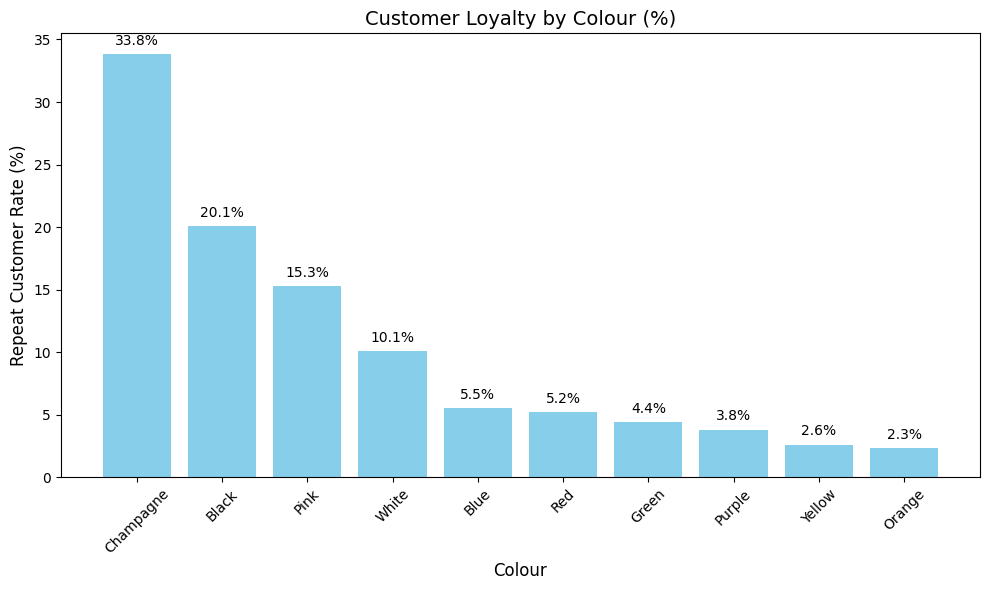

In [ ]:
import matplotlib.pyplot as plt

# Sort colours by loyalty rate (highest to lowest)
top_colours = colour_loyalty.sort_values(by="repeat_customer_rate", ascending=False)

# Create bar plot
plt.figure(figsize=(10, 6))
bars = plt.bar(top_colours["colour"], top_colours["repeat_customer_rate"], color='skyblue')

# Titles and labels
plt.title("Customer Loyalty by Colour (%)", fontsize=14)
plt.xlabel("Colour", fontsize=12)
plt.ylabel("Repeat Customer Rate (%)", fontsize=12)
plt.xticks(rotation=45)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.5,
        f"{height:.1f}%",
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.tight_layout()
plt.show()


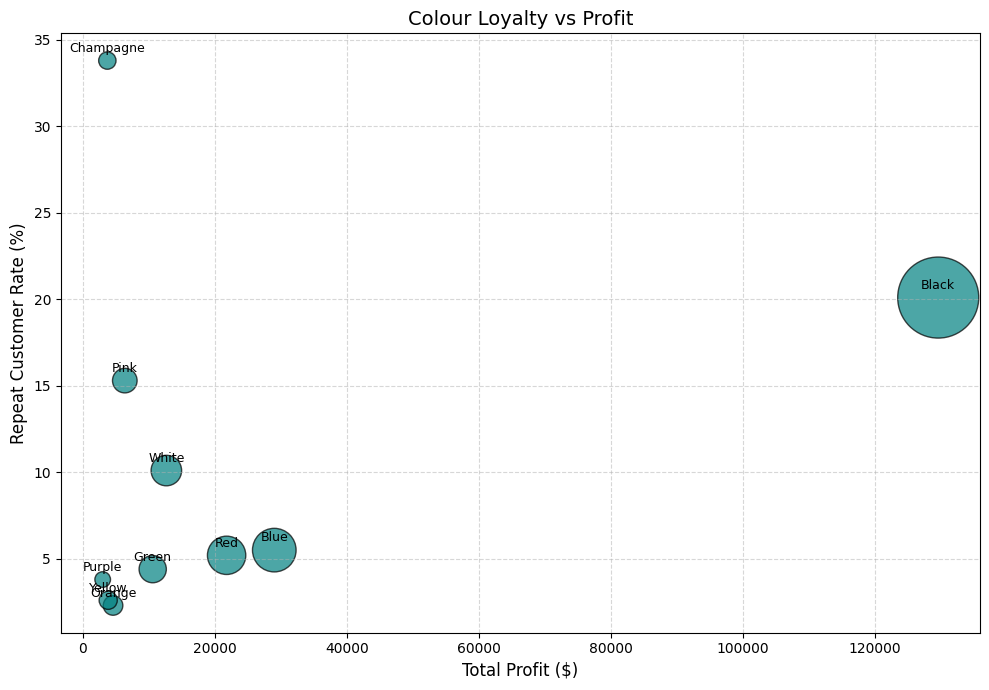

In [ ]:
import matplotlib.pyplot as plt

# Set up plot
plt.figure(figsize=(10, 7))

# Bubble scatter plot
scatter = plt.scatter(
    colour_loyalty["total_profit"],
    colour_loyalty["repeat_customer_rate"],
    s=colour_loyalty["total_units"] * 0.5,  # bubble size scaled
    c='teal',
    alpha=0.7,
    edgecolors='black'
)

# Add labels on points
for i, row in colour_loyalty.iterrows():
    plt.text(row["total_profit"], row["repeat_customer_rate"] + 0.5, row["colour"], fontsize=9, ha='center')

# Titles and axes
plt.title("Colour Loyalty vs Profit", fontsize=14)
plt.xlabel("Total Profit ($)", fontsize=12)
plt.ylabel("Repeat Customer Rate (%)", fontsize=12)

# Grid and styling
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


In [ ]:
# STEP X: Filter valid rows (non-bundles, real items, exclude 'custom' colours)
valid_sales = merged_df[
    (~merged_df["is_bundle_header"]) &                 # not a bundle header
    (~merged_df["is_bundle_component"]) &              # not a bundle component
    (merged_df["colour"].str.lower() != "custom") &    # exclude 'custom'
    (merged_df["qty_minus_refund"] > 0)                # real quantity sold
].copy()

# STEP Y: Calculate item-level profit
valid_sales["profit"] = (
    (valid_sales["item_price_inc_tax"] - valid_sales["cost"]) * valid_sales["qty_minus_refund"]
)

# STEP Z: Total sales & profit by colour
colour_sales = valid_sales.groupby("colour").agg(
    total_units=("qty_minus_refund", "sum"),
    total_orders=("order_id", "nunique"),
    total_profit=("profit", "sum")
).reset_index()

# Attach customer_email from orders_df to valid_sales
orders_df["order_id"] = orders_df["order_id"].astype(str)
valid_sales["order_id"] = valid_sales["order_id"].astype(str)

valid_sales = valid_sales.merge(
    orders_df[["order_id", "customer_email"]],
    on="order_id", how="left"
)
valid_sales["customer_id"] = valid_sales["customer_email"].astype(str)

# Track repeat colour purchases (same colour by same customer)
repeat_colour_purchases = valid_sales.groupby(["customer_id", "colour"]).agg(
    times_purchased=("order_id", "count")
).reset_index()

# Flag repeated purchases
repeated = repeat_colour_purchases[repeat_colour_purchases["times_purchased"] > 1]

repeat_customers = repeated.groupby("colour").agg(
    repeat_customers=("customer_id", "nunique")
).reset_index()

# Final merge & compute loyalty
colour_loyalty = pd.merge(colour_sales, repeat_customers, on="colour", how="left")
colour_loyalty["repeat_customers"] = colour_loyalty["repeat_customers"].fillna(0).astype(int)
colour_loyalty["repeat_customer_rate"] = (
    colour_loyalty["repeat_customers"] / colour_loyalty["total_orders"]
).round(3) * 100

# Optional: Sort results for insight
colour_loyalty = colour_loyalty.sort_values(by="repeat_customer_rate", ascending=False)

# Display
colour_loyalty.head(10)


,colour,total_units,total_orders,total_profit,repeat_customers,repeat_customer_rate
2,Champagne,313,225,3747.88,76,33.8
0,Black,6812,5443,129556.45,1096,20.1
5,Pink,628,531,6392.38,81,15.3
8,White,967,849,12683.47,86,10.1
1,Blue,1972,1840,29027.28,101,5.5
7,Red,1525,1415,21806.26,74,5.2
3,Green,771,722,10617.92,32,4.4
6,Purple,254,235,3042.22,9,3.8
9,Yellow,342,311,3877.17,8,2.6
4,Orange,397,355,4612.65,8,2.3


In [ ]:
# 1. Number of colours in a bundle
headers_df["num_colours_in_bundle"] = headers_df["colours_in_bundle"].apply(
    lambda x: len(x.split(", ")) if isinstance(x, str) else 0
)

# 2. Whether the colour combo is one of the top profit mixes
top_colours = ["Black, Blue, Green, Red", "Black, Blue, Red"]  # Example from visual
headers_df["is_top_colour_mix"] = headers_df["colours_in_bundle"].isin(top_colours).astype(int)

# 3. Whether Black is included
headers_df["includes_black"] = headers_df["colours_in_bundle"].apply(
    lambda x: "Black" in x if isinstance(x, str) else False
).astype(int)

# 4. Encode bundle_type
headers_df["bundle_type_encoded"] = headers_df["bundle_type"].astype("category").cat.codes

# 5. Rank colour combos by total profit
profit_by_combo = (
    headers_df.groupby("colours_in_bundle")["true_bundle_profit"]
    .sum()
    .sort_values(ascending=False)
)
combo_rank = profit_by_combo.rank(ascending=False).astype(int).to_dict()

headers_df["product_colour_combo_rank"] = headers_df["colours_in_bundle"].map(combo_rank).fillna(0).astype(int)


In [ ]:
# STEP 1: Ensure 'billing_region' is merged into the main dataset
merged_df["order_id"] = merged_df["order_id"].astype(str)
orders_df["order_id"] = orders_df["order_id"].astype(str)

# Fix column name here if needed
merged_df = merged_df.merge(
    orders_df[["order_id", "billing_region"]],
    on="order_id", how="left"
)

# STEP 2: Calculate profit if not already present
merged_df["profit"] = (
    (merged_df["item_price_inc_tax"] - merged_df["cost"]) * merged_df["qty_minus_refund"]
)

# STEP 3: Group by colour, brand, and billing region
top_colour_region = merged_df.groupby(
    ["colour", "brand", "billing_region"]
).agg(
    total_profit=("profit", "sum"),
    total_units=("qty_minus_refund", "sum"),
    order_count=("order_id", "nunique")
).sort_values(by="total_profit", ascending=False).reset_index()

# STEP 4: Display
top_colour_region.head(10)


,colour,brand,billing_region,total_profit,total_units,order_count
0,Custom,Adam,New South Wales,28595.99,456,441
1,Custom,Adam,Victoria,27726.46,415,404
2,Custom,Adam,New Zealand,25067.81,402,392
3,Custom,Adam,Intl Zone B,21686.68,316,304
4,Custom,Adam,Australian Capital Territory,21212.80,338,335
5,Custom,Adam,Tasmania,19409.02,314,308
6,Custom,Adam,Queensland,17521.31,288,279
7,Custom,Adam,South Australia,16704.39,278,271
8,Custom,Adam,Northern Territory,14469.79,231,230
9,Custom,Adam,Western Australia,14322.63,237,232


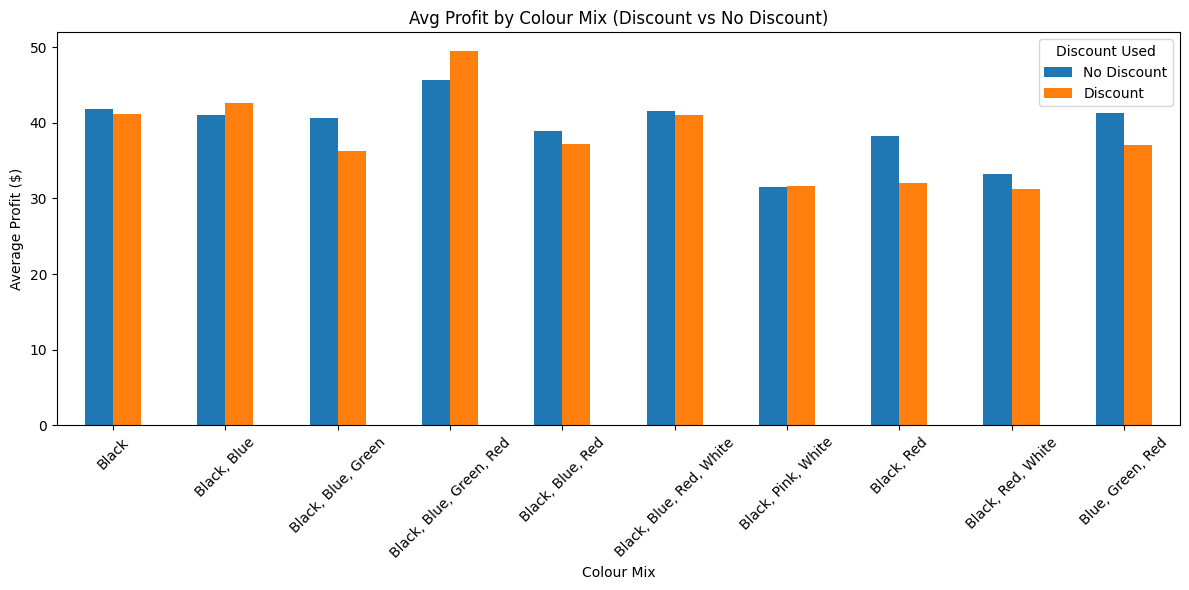

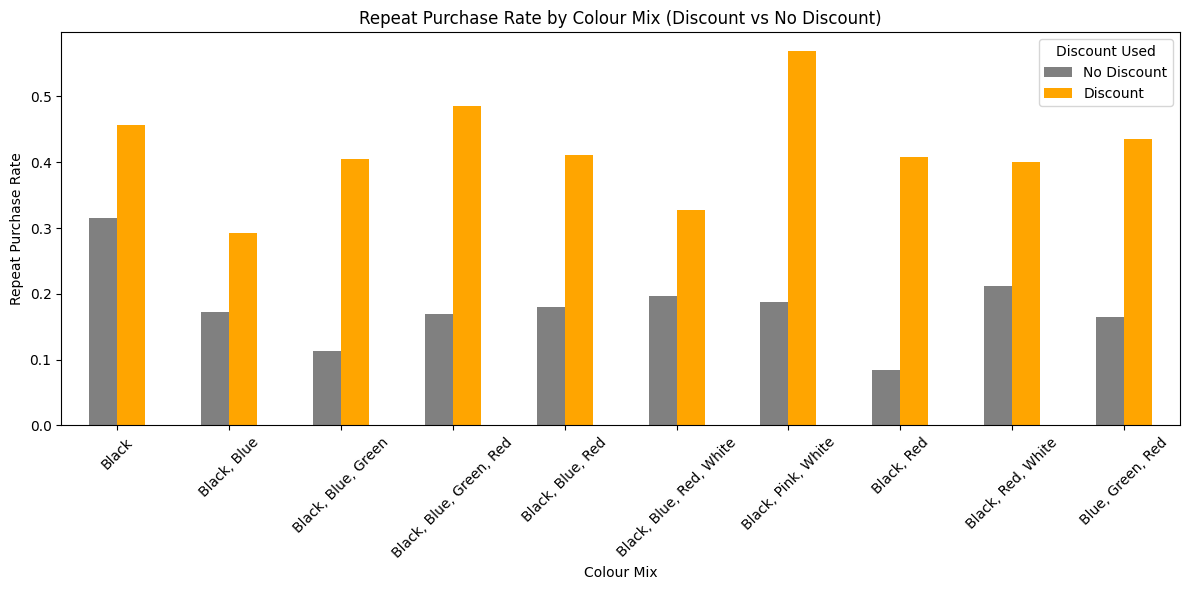

In [ ]:
# Ensure 'repeat_customer' exists
headers_df["repeat_customer"] = headers_df.groupby("customer_id")["order_id"].transform("count") > 1
headers_df["repeat_customer"] = headers_df["repeat_customer"].astype(int)

# Create df_model (subset of headers_df if not already done)
df_model = headers_df[headers_df["repeat_customer"].notna()].copy()

# Fill NaNs in discount column
df_model["first_order_discount_pc"] = df_model["first_order_discount_pc"].fillna(0)
df_model["has_discount"] = df_model["first_order_discount_pc"] > 0

# Step 1: Group by colour, discount status, then calculate metrics
colour_discount_perf = df_model.groupby(["colours_in_bundle", "has_discount"]).agg(
    avg_profit=("true_bundle_profit", "mean"),
    repeat_rate=("repeat_customer", "mean"),
    bundle_count=("order_id", "count")
).reset_index()

# Step 2: Filter for popular colour mixes (optional clarity)
top_colours = (
    df_model["colours_in_bundle"]
    .value_counts()
    .nlargest(10)
    .index
)

filtered_perf = colour_discount_perf[colour_discount_perf["colours_in_bundle"].isin(top_colours)]

# Step 3: Plot comparisons

# Pivot for plotting
pivot_profit = filtered_perf.pivot(index="colours_in_bundle", columns="has_discount", values="avg_profit")
pivot_repeat = filtered_perf.pivot(index="colours_in_bundle", columns="has_discount", values="repeat_rate")

import matplotlib.pyplot as plt

# Profit comparison
pivot_profit.plot(kind="bar", figsize=(12, 6))
plt.title("Avg Profit by Colour Mix (Discount vs No Discount)")
plt.xlabel("Colour Mix")
plt.ylabel("Average Profit ($)")
plt.xticks(rotation=45)
plt.legend(["No Discount", "Discount"], title="Discount Used", loc="upper right")
plt.tight_layout()
plt.show()

# Repeat rate comparison
pivot_repeat.plot(kind="bar", figsize=(12, 6), color=["grey", "orange"])
plt.title("Repeat Purchase Rate by Colour Mix (Discount vs No Discount)")
plt.xlabel("Colour Mix")
plt.ylabel("Repeat Purchase Rate")
plt.xticks(rotation=45)
plt.legend(["No Discount", "Discount"], title="Discount Used", loc="upper right")
plt.tight_layout()
plt.show()


<Figure size 1400x600 with 0 Axes>

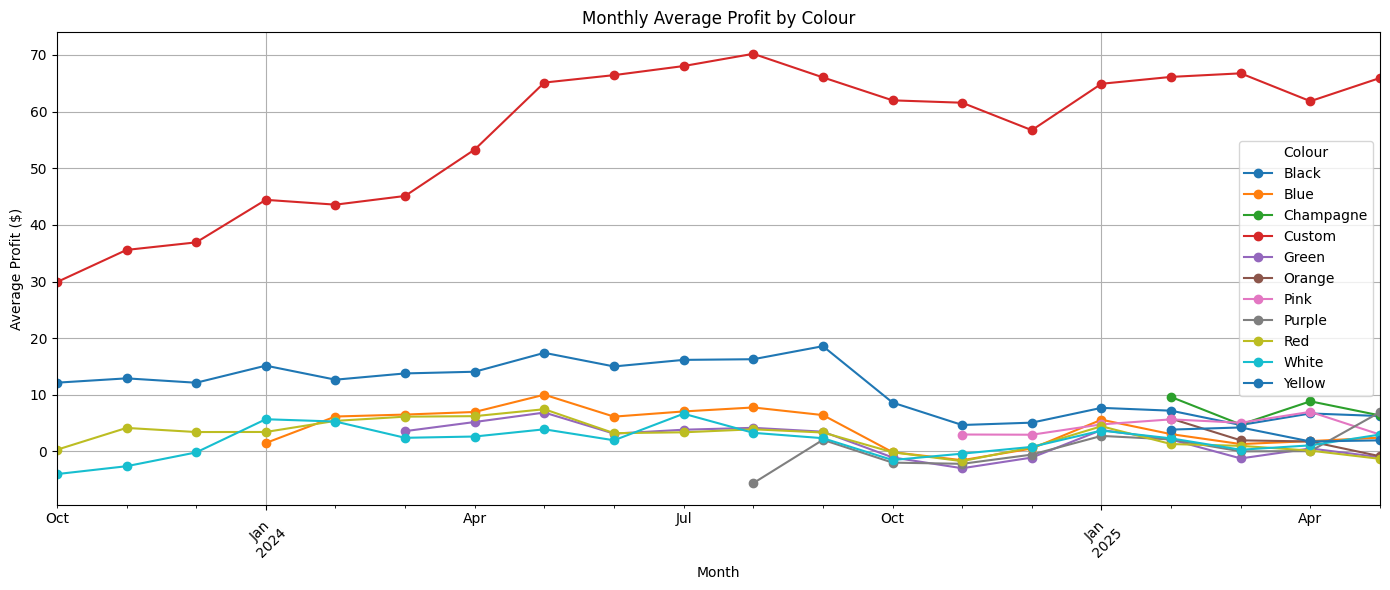

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# STEP 0: Merge order_date into merged_df (if not already done)
orders_df["order_id"] = orders_df["order_id"].astype(str)
merged_df["order_id"] = merged_df["order_id"].astype(str)

merged_df = merged_df.merge(
    orders_df[["order_id", "order_date"]],
    on="order_id",
    how="left"
)

# STEP 1: Recalculate profit if not already done
merged_df["profit"] = (
    (merged_df["item_price_inc_tax"] - merged_df["cost"]) * merged_df["qty_minus_refund"]
)

# STEP 2: Create monthly field from order_date
merged_df["order_date"] = pd.to_datetime(merged_df["order_date"])  # Convert to datetime if needed
merged_df["order_month"] = merged_df["order_date"].dt.to_period("M")

# STEP 3: Calculate monthly average profit per colour
monthly_profit = (
    merged_df[merged_df["colour"].notna()]
    .groupby(["order_month", "colour"])["profit"]
    .mean()
    .reset_index()
)

# STEP 4: Pivot for plotting
profit_pivot = monthly_profit.pivot(index="order_month", columns="colour", values="profit")

# STEP 5: Plot monthly profit trend by colour
plt.figure(figsize=(14, 6))
profit_pivot.plot(marker='o', figsize=(14, 6))
plt.title("Monthly Average Profit by Colour")
plt.xlabel("Month")
plt.ylabel("Average Profit ($)")
plt.xticks(rotation=45)
plt.grid(True)
plt.legend(title="Colour")
plt.tight_layout()
plt.show()


In [28]:
print("orders_df columns:", orders_df.columns.tolist())
print("merged_df columns:", merged_df.columns.tolist())

orders_df columns: ['order_id', 'customer_email', 'order_date', 'order_seq', 'billing_region', 'cart_discount', 'discount_amount_inc_tax', 'gender_billing', 'gender_shipping', 'order_cost', 'order_qty_charged', 'order_qty_minus_refund', 'order_refund', 'order_shipping_inc_tax', 'order_subtotal_inc_tax', 'order_total', 'order_total_fee_inc', 'order_units', 'payment_method_title', 'shipping_method_title', 'shipping_region', 'discount_pc']
merged_df columns: ['order_id_line_id', 'order_id', 'line_id', 'pvr_id', 'cost', 'item_discount_amount_and_tax', 'item_price_before_discount_inc', 'item_price_inc_tax', 'line_discount_amount_inc_tax', 'line_price_before_discount_inc', 'qty_charged', 'qty_minus_refund', 'units', 'product_id', 'variation_id', 'range', 'product_type', 'pack_size', 'product_name_main', 'name', 'size', 'price', 'type', 'category', 'colour', 'brand', 'is_bundle_header', 'is_bundle_component', 'profit', 'billing_region', 'order_date', 'order_month', 'customer_email_x', 'custom


--- Logistic Regression ---
Accuracy: 0.7146464646464646
Precision: 0.7705882352941177
Recall: 0.3039443155452436
F1 Score: 0.43594009983361065
ROC AUC: 0.7204145684362808
Confusion Matrix:
 [[718  39]
 [300 131]]
Classification Report:
               precision    recall  f1-score   support

           0       0.71      0.95      0.81       757
           1       0.77      0.30      0.44       431

    accuracy                           0.71      1188
   macro avg       0.74      0.63      0.62      1188
weighted avg       0.73      0.71      0.67      1188



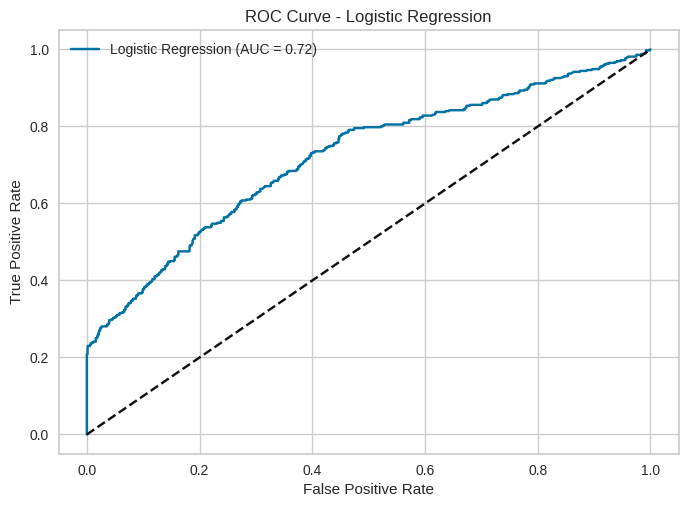


--- Decision Tree ---
Accuracy: 0.7163299663299664
Precision: 0.6211340206185567
Recall: 0.5591647331786543
F1 Score: 0.5885225885225885
ROC AUC: 0.6971989199030243
Confusion Matrix:
 [[610 147]
 [190 241]]
Classification Report:
               precision    recall  f1-score   support

           0       0.76      0.81      0.78       757
           1       0.62      0.56      0.59       431

    accuracy                           0.72      1188
   macro avg       0.69      0.68      0.69      1188
weighted avg       0.71      0.72      0.71      1188



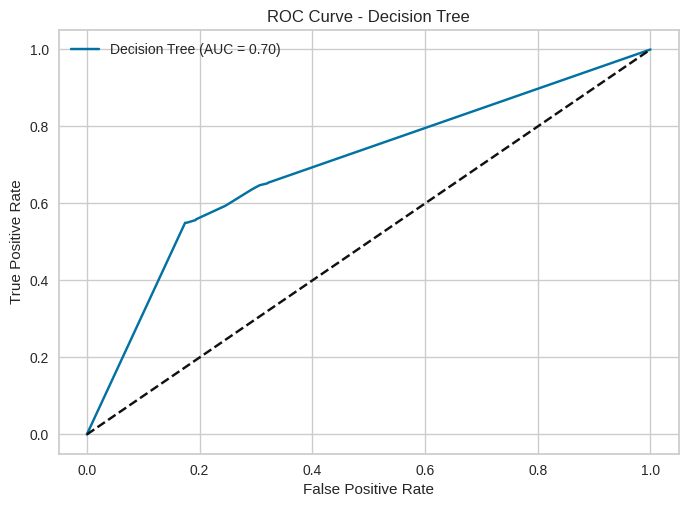


--- Random Forest ---
Accuracy: 0.7230639730639731
Precision: 0.6401098901098901
Recall: 0.5406032482598608
F1 Score: 0.5861635220125786
ROC AUC: 0.7420778074399188
Confusion Matrix:
 [[626 131]
 [198 233]]
Classification Report:
               precision    recall  f1-score   support

           0       0.76      0.83      0.79       757
           1       0.64      0.54      0.59       431

    accuracy                           0.72      1188
   macro avg       0.70      0.68      0.69      1188
weighted avg       0.72      0.72      0.72      1188



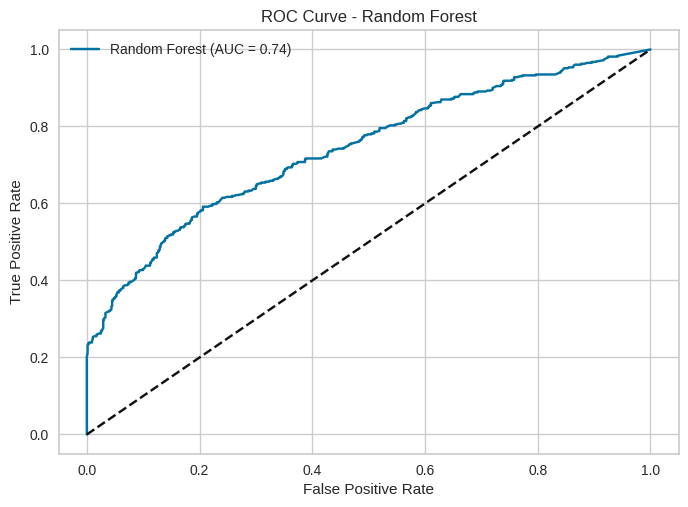

In [36]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix, roc_curve
)
import matplotlib.pyplot as plt

# ---------------------------------------------
# 1. Preprocess headers_df
# ---------------------------------------------

# Repeat customer flag
headers_df["repeat_customer"] = headers_df.groupby("customer_id")["order_id"].transform("count") > 1
headers_df["repeat_customer"] = headers_df["repeat_customer"].astype(int)

# Fill missing discount
headers_df["first_order_discount_pc"] = headers_df["first_order_discount_pc"].fillna(0)
headers_df["discount_used"] = (headers_df["first_order_discount_pc"] > 0).astype(int)

# Number of colours in bundle
headers_df["num_colours_in_bundle"] = headers_df["colours_in_bundle"].apply(
    lambda x: len(set(x.split(", "))) if isinstance(x, str) else 1
)

# Includes black
headers_df["includes_black"] = headers_df["colours_in_bundle"].str.contains("black", case=False, na=False).astype(int)

# Top 10 colour mixes (from earlier analysis)
top_colours = (
    headers_df["colours_in_bundle"]
    .value_counts()
    .nlargest(10)
    .index
)
headers_df["is_top_colour_mix"] = headers_df["colours_in_bundle"].isin(top_colours).astype(int)

# Extract time features
headers_df["order_date"] = pd.to_datetime(headers_df["order_date"])
headers_df["order_dayofweek"] = headers_df["order_date"].dt.dayofweek
headers_df["is_weekend"] = headers_df["order_dayofweek"].isin([5, 6]).astype(int)

# Merge billing_region from orders_df
orders_df["order_id"] = orders_df["order_id"].astype(str)
headers_df["order_id"] = headers_df["order_id"].astype(str)
headers_df = headers_df.merge(
    orders_df[["order_id", "billing_region"]],
    on="order_id", how="left"
)

# ---------------------------------------------
# 2. Feature Engineering & Encoding
# ---------------------------------------------
features = [
    "first_order_discount_pc", "discount_used", "num_colours_in_bundle",
    "includes_black", "is_top_colour_mix", "order_dayofweek", "is_weekend"
]

# Encode categorical: bundle_type, billing_region
categorical_cols = ["bundle_type", "billing_region"]
headers_df[categorical_cols] = headers_df[categorical_cols].fillna("unknown")

# One-hot encoding
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

encoded_cats = encoder.fit_transform(headers_df[categorical_cols])
encoded_cat_df = pd.DataFrame(encoded_cats, columns=encoder.get_feature_names_out(categorical_cols))

# Combine features
df_model = pd.concat([headers_df[features + ["repeat_customer"]].reset_index(drop=True), encoded_cat_df], axis=1)

# Drop missing targets or features
df_model = df_model.dropna(subset=["repeat_customer"])
X = df_model.drop(columns=["repeat_customer"])
y = df_model["repeat_customer"].astype(int)

# ---------------------------------------------
# 3. Train/Test Split & Scaling
# ---------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ---------------------------------------------
# 4. Define Models
# ---------------------------------------------
models = {
    "Logistic Regression": LogisticRegression(solver="liblinear"),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

# ---------------------------------------------
# 5. Evaluate
# ---------------------------------------------
for name, model in models.items():
    print(f"\n--- {name} ---")

    if name == "Logistic Regression":
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        y_proba = model.predict_proba(X_test_scaled)[:, 1]
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_proba = model.predict_proba(X_test)[:, 1]

    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("F1 Score:", f1_score(y_test, y_pred))
    print("ROC AUC:", roc_auc_score(y_test, y_proba))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("Classification Report:\n", classification_report(y_test, y_pred))

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.figure()
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc_score(y_test, y_proba):.2f})")
    plt.plot([0, 1], [0, 1], "k--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve - {name}")
    plt.legend()
    plt.grid(True)
    plt.show()


Fitting 5 folds for each of 48 candidates, totalling 240 fits
Best Parameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}
Accuracy: 0.7466329966329966
Precision: 0.7443609022556391
Recall: 0.4593967517401392
F1 Score: 0.5681492109038737
ROC AUC: 0.7596799553739729
Confusion Matrix:
 [[689  68]
 [233 198]]
Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.91      0.82       757
           1       0.74      0.46      0.57       431

    accuracy                           0.75      1188
   macro avg       0.75      0.68      0.69      1188
weighted avg       0.75      0.75      0.73      1188



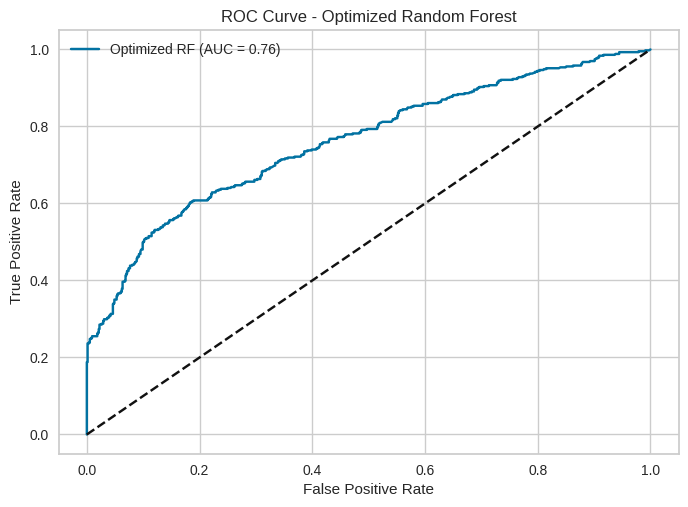

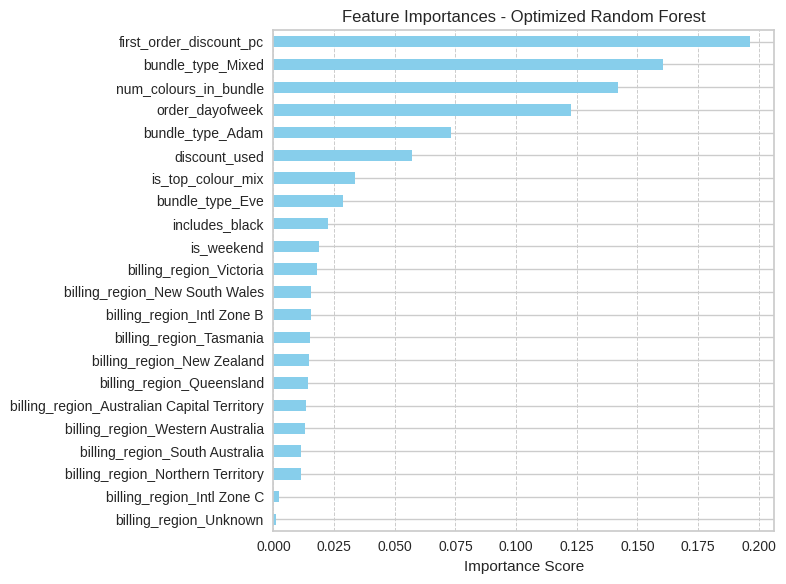

In [37]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    precision_score, recall_score, f1_score, roc_auc_score, roc_curve
)
import matplotlib.pyplot as plt
import pandas as pd

# STEP 1: Define the parameter grid for tuning
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2']
}

# STEP 2: Stratified Cross-Validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# STEP 3: Initialize the Random Forest model
rf = RandomForestClassifier(random_state=42)

# STEP 4: Perform Grid Search with cross-validation
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring='f1',
    cv=cv,
    n_jobs=-1,
    verbose=1
)

# STEP 5: Fit the model to training data
grid_search.fit(X_train, y_train)

# STEP 6: Get the best model
best_model = grid_search.best_estimator_
print("Best Parameters:", grid_search.best_params_)

# STEP 7: Predict on test set
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

# STEP 8: Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

# STEP 9: Plot ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure()
plt.plot(fpr, tpr, label=f"Optimized RF (AUC = {roc_auc_score(y_test, y_proba):.2f})")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Optimized Random Forest")
plt.legend()
plt.grid(True)
plt.show()

# STEP 10: Plot Feature Importances
importances = pd.Series(best_model.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=True)

plt.figure(figsize=(8, 6))
importances.plot(kind='barh', color='skyblue')
plt.title("Feature Importances - Optimized Random Forest")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.grid(axis='x', linestyle='--', linewidth=0.7)
plt.show()


In [86]:
# --- SETUP ---
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# --- TARGET VARIABLE ---
headers_df["total_clv"] = headers_df["true_bundle_profit"].fillna(0)

# --- FEATURE ENGINEERING ---
headers_df["first_order_discount_pc"] = headers_df["first_order_discount_pc"].fillna(0)
headers_df["discount_used"] = (headers_df["first_order_discount_pc"] > 0).astype(int)
headers_df["colours_in_bundle"] = headers_df["colours_in_bundle"].fillna("Unknown")
headers_df["num_colours_in_bundle"] = headers_df["colours_in_bundle"].apply(lambda x: len(str(x).split(", ")))
headers_df["includes_black"] = headers_df["colours_in_bundle"].str.contains("black", case=False, na=False).astype(int)

top_colours = headers_df["colours_in_bundle"].value_counts().nlargest(10).index
headers_df["is_top_colour_mix"] = headers_df["colours_in_bundle"].isin(top_colours).astype(int)
headers_df["colours_in_bundle_encoded"] = LabelEncoder().fit_transform(headers_df["colours_in_bundle"])
headers_df["bundle_type_encoded"] = LabelEncoder().fit_transform(headers_df["bundle_type"].astype(str))

# --- MODEL INPUTS ---
features = [
    "item_price_inc_tax", "first_order_discount_pc", "discount_used",
    "colours_in_bundle_encoded", "num_colours_in_bundle", "includes_black",
    "is_top_colour_mix", "bundle_type_encoded"
]
target = "total_clv"

# --- MERGE RANGE BACK ---
df_model = headers_df.dropna(subset=features + [target]).copy()
range_info = merged_df[["order_id", "range"]].drop_duplicates()
df_model = df_model.merge(range_info, on="order_id", how="left")

# --- TRAINING SETUP ---
X = df_model[features]
y = df_model[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- MODELS ---
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree Regressor": DecisionTreeRegressor(random_state=42),
    "Random Forest Regressor": RandomForestRegressor(n_estimators=100, random_state=42)
}

# --- TRAIN & PREDICT ---
results = {}
predictions = {}

for name, model in models.items():
    if name == "Linear Regression":
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        predictions[name] = model.predict(scaler.transform(X))
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        predictions[name] = model.predict(X)

    results[name] = {
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
        "MAE": mean_absolute_error(y_test, y_pred),
        "R2": r2_score(y_test, y_pred)
    }

# --- ADD PREDICTIONS ---
df_model["predicted_clv_lr"] = predictions["Linear Regression"]
df_model["predicted_clv_dt"] = predictions["Decision Tree Regressor"]
df_model["predicted_clv_rf"] = predictions["Random Forest Regressor"]

# --- EXPORT TO CSV ---
df_model.to_csv("clv_predictions_all_models.csv", index=False)
print("Exported to clv_predictions_all_models.csv")

# --- OPTIONAL: PRINT RESULTS ---
results_df = pd.DataFrame(results).T
print("\nModel Performance:")
print(results_df)


Exported to clv_predictions_all_models.csv

Model Performance:
                             RMSE       MAE        R2
Linear Regression        6.933640  3.821002  0.866567
Decision Tree Regressor  4.696073  1.054469  0.938792
Random Forest Regressor  4.265574  1.304746  0.949499


Model Performance:

                             RMSE       MAE        R2
Linear Regression        6.933640  3.821002  0.866567
Decision Tree Regressor  4.696073  1.054469  0.938792
Random Forest Regressor  4.265574  1.304746  0.949499


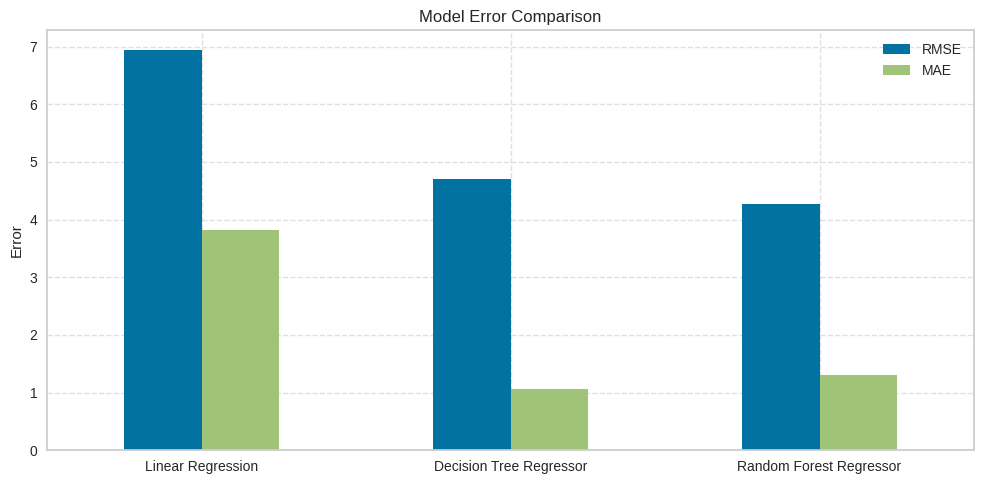

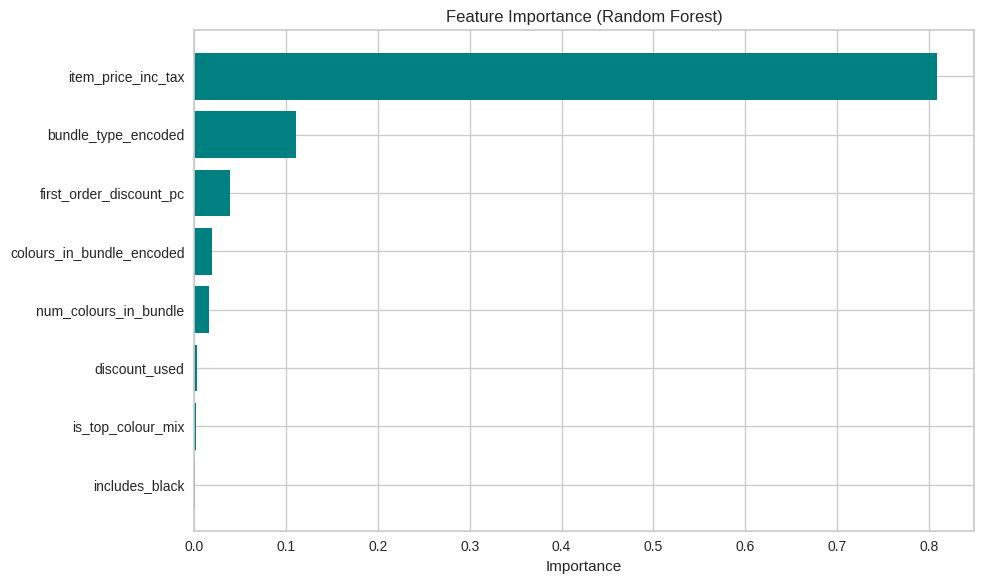

In [88]:
# --- SETUP ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# --- TARGET VARIABLE ---
headers_df["total_clv"] = headers_df["true_bundle_profit"].fillna(0)

# --- FEATURE ENGINEERING ---
headers_df["first_order_discount_pc"] = headers_df["first_order_discount_pc"].fillna(0)
headers_df["discount_used"] = (headers_df["first_order_discount_pc"] > 0).astype(int)
headers_df["colours_in_bundle"] = headers_df["colours_in_bundle"].fillna("Unknown")
headers_df["num_colours_in_bundle"] = headers_df["colours_in_bundle"].apply(lambda x: len(str(x).split(", ")))
headers_df["includes_black"] = headers_df["colours_in_bundle"].str.contains("black", case=False, na=False).astype(int)

top_colours = headers_df["colours_in_bundle"].value_counts().nlargest(10).index
headers_df["is_top_colour_mix"] = headers_df["colours_in_bundle"].isin(top_colours).astype(int)
headers_df["colours_in_bundle_encoded"] = LabelEncoder().fit_transform(headers_df["colours_in_bundle"])
headers_df["bundle_type_encoded"] = LabelEncoder().fit_transform(headers_df["bundle_type"].astype(str))

# --- MODEL INPUTS ---
features = [
    "item_price_inc_tax", "first_order_discount_pc", "discount_used",
    "colours_in_bundle_encoded", "num_colours_in_bundle", "includes_black",
    "is_top_colour_mix", "bundle_type_encoded"
]
target = "total_clv"

# --- MERGE RANGE BACK ---
df_model = headers_df.dropna(subset=features + [target]).copy()
range_info = merged_df[["order_id", "range"]].drop_duplicates()
df_model = df_model.merge(range_info, on="order_id", how="left")

# --- TRAINING SETUP ---
X = df_model[features]
y = df_model[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- MODELS ---
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree Regressor": DecisionTreeRegressor(random_state=42),
    "Random Forest Regressor": RandomForestRegressor(n_estimators=100, random_state=42)
}

results = {}
predictions = {}

for name, model in models.items():
    if name == "Linear Regression":
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        predictions[name] = model.predict(scaler.transform(X))
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        predictions[name] = model.predict(X)

    results[name] = {
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
        "MAE": mean_absolute_error(y_test, y_pred),
        "R2": r2_score(y_test, y_pred)
    }

# --- ADD PREDICTIONS ---
df_model["predicted_clv_lr"] = predictions["Linear Regression"]
df_model["predicted_clv_dt"] = predictions["Decision Tree Regressor"]
df_model["predicted_clv_rf"] = predictions["Random Forest Regressor"]

# --- EXPORT ---
df_model.to_csv("clv_predictions_all_models.csv", index=False)

# --- DISPLAY RESULTS ---
results_df = pd.DataFrame(results).T
print("Model Performance:\n")
print(results_df)

# --- PLOT 1: MODEL COMPARISON ---
results_df[["RMSE", "MAE"]].plot(kind="bar", figsize=(10, 5), title="Model Error Comparison")
plt.ylabel("Error")
plt.xticks(rotation=0)
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

# --- PLOT 2: FEATURE IMPORTANCE (Random Forest) ---
importances = models["Random Forest Regressor"].feature_importances_
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(importance_df["Feature"], importance_df["Importance"], color="teal")
plt.xlabel("Importance")
plt.title("Feature Importance (Random Forest)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


Model Performance:

                             RMSE       MAE        R2
Linear Regression        6.933640  3.821002  0.866567
Decision Tree Regressor  4.696073  1.054469  0.938792
Random Forest Regressor  4.265574  1.304746  0.949499


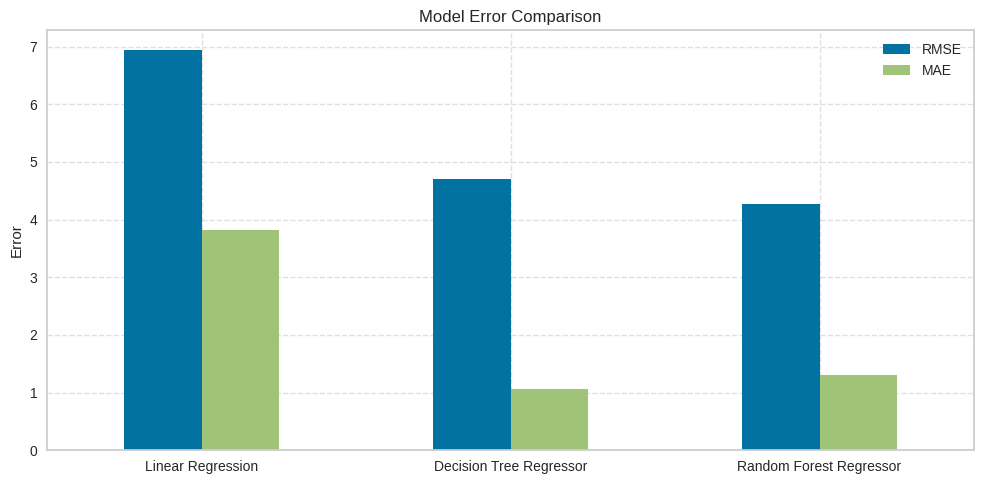

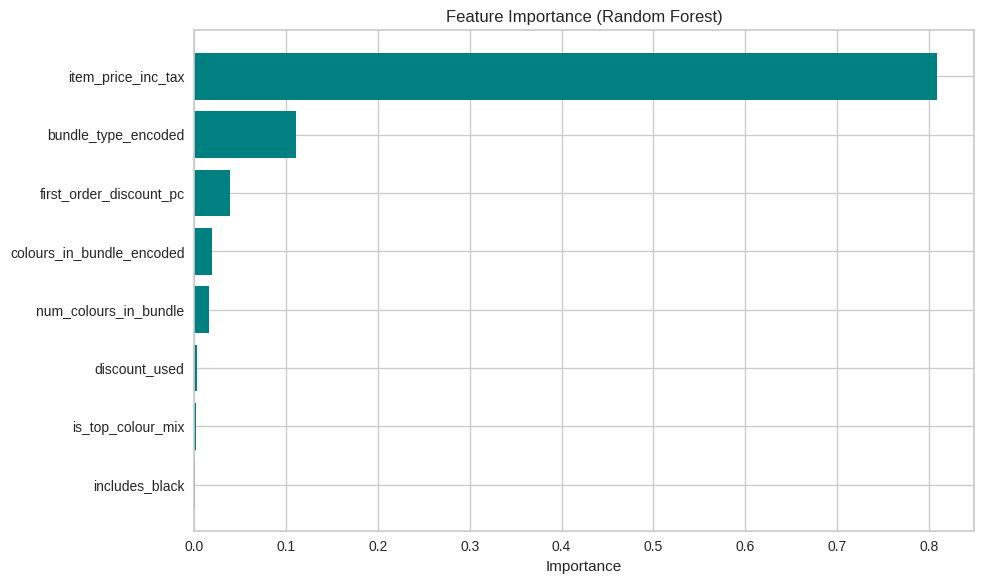

In [96]:
# --- SETUP ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# --- TARGET VARIABLE ---
headers_df["total_clv"] = headers_df["true_bundle_profit"].fillna(0)

# --- FEATURE ENGINEERING ---
headers_df["first_order_discount_pc"] = headers_df["first_order_discount_pc"].fillna(0)
headers_df["discount_used"] = (headers_df["first_order_discount_pc"] > 0).astype(int)
headers_df["colours_in_bundle"] = headers_df["colours_in_bundle"].fillna("Unknown")
headers_df["num_colours_in_bundle"] = headers_df["colours_in_bundle"].apply(lambda x: len(str(x).split(", ")))
headers_df["includes_black"] = headers_df["colours_in_bundle"].str.contains("black", case=False, na=False).astype(int)

top_colours = headers_df["colours_in_bundle"].value_counts().nlargest(10).index
headers_df["is_top_colour_mix"] = headers_df["colours_in_bundle"].isin(top_colours).astype(int)
headers_df["colours_in_bundle_encoded"] = LabelEncoder().fit_transform(headers_df["colours_in_bundle"])
headers_df["bundle_type_encoded"] = LabelEncoder().fit_transform(headers_df["bundle_type"].astype(str))

# --- MODEL INPUTS ---
features = [
    "item_price_inc_tax", "first_order_discount_pc", "discount_used",
    "colours_in_bundle_encoded", "num_colours_in_bundle", "includes_black",
    "is_top_colour_mix", "bundle_type_encoded"
]
target = "total_clv"

# --- MERGE RANGE BACK ---
headers_df["order_id"] = headers_df["order_id"].astype(str)
merged_df["order_id"] = merged_df["order_id"].astype(str)
range_info = merged_df[["order_id", "range"]].drop_duplicates()
df_model = headers_df.dropna(subset=features + [target]).copy()
df_model = df_model.merge(range_info, on="order_id", how="left")

# --- TRAINING SETUP ---
X = df_model[features]
y = df_model[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- MODELS ---
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree Regressor": DecisionTreeRegressor(random_state=42),
    "Random Forest Regressor": RandomForestRegressor(n_estimators=100, random_state=42)
}

results = {}
predictions = {}

# --- TRAIN & PREDICT ---
for name, model in models.items():
    if name == "Linear Regression":
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        predictions[name] = model.predict(scaler.transform(X))
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        predictions[name] = model.predict(X)

    results[name] = {
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
        "MAE": mean_absolute_error(y_test, y_pred),
        "R2": r2_score(y_test, y_pred)
    }

# --- ADD PREDICTIONS ---
df_model["predicted_clv_lr"] = predictions["Linear Regression"]
df_model["predicted_clv_dt"] = predictions["Decision Tree Regressor"]
df_model["predicted_clv_rf"] = predictions["Random Forest Regressor"]

# --- EXPORT ---
df_model.to_csv("clv_predictions_final_with_range.csv", index=False)

# --- DISPLAY RESULTS ---
results_df = pd.DataFrame(results).T
print("Model Performance:\n")
print(results_df)

# --- PLOT 1: MODEL PERFORMANCE ---
results_df[["RMSE", "MAE"]].plot(kind="bar", figsize=(10, 5), title="Model Error Comparison")
plt.ylabel("Error")
plt.xticks(rotation=0)
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

# --- PLOT 2: FEATURE IMPORTANCE ---
importances = models["Random Forest Regressor"].feature_importances_
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(importance_df["Feature"], importance_df["Importance"], color="teal")
plt.xlabel("Importance")
plt.title("Feature Importance (Random Forest)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()
